In [1]:
import duckdb
import matplotlib.pyplot as plt
import polars as pl
import seaborn as sns

pl.Config(fmt_str_lengths=1000, tbl_width_chars=1000)
pl.Config(tbl_rows=20)

In [2]:
conn = duckdb.connect("amfi.duckdb")

In [3]:
# # List of tables/views to preserve
# EXCEPTIONS = (
#     'raw_fund_house', 'raw_scheme', 'raw_scheme_document', 'raw_scheme_aum',
#     'raw_nav_plan_details', 'raw_nav'
# )

# # 1. Construct the query to find targets
# # Note: information_schema.tables includes both 'BASE TABLE' and 'VIEW'
# query = f"""
#     SELECT 
#         CASE WHEN table_type = 'BASE TABLE' THEN 'TABLE' ELSE 'VIEW' END as type,
#         table_name
#     FROM information_schema.tables
#     WHERE table_schema = 'main'
#       AND table_name NOT IN {EXCEPTIONS}
# """

# # 2. Fetch and execute
# targets = conn.execute(query).fetchall()
# print(targets)

# if targets:
#     # Build DROP statements with proper quoting
#     drop_statements = " ".join([f"DROP {t[0]} IF EXISTS \"{t[1]}\";" for t in targets])
    
#     # Execute as a single atomic block
#     conn.execute(f"BEGIN TRANSACTION; {drop_statements} COMMIT;")

In [4]:
conn.execute(
    """
    WITH nav AS (
        SELECT distinct sd_id
        FROM nav_v
    )
    SELECT np.sd_id np_sd_id, n.sd_id nav_sd_id
    FROM nav_plan_details_v np
    FULL OUTER JOIN nav n USING (sd_id)
    WHERE np.sd_id IS NULL OR n.sd_id IS NULL
    """
).pl()

np_sd_id,nav_sd_id
i32,i32


In [5]:
conn.execute(
    """
    WITH np AS (
        SELECT distinct fund_house
        FROM nav_plan_details_v
    )
    SELECT np.fund_house np_fund_house, fh.fund_house fh_fund_house
    FROM np
    FULL OUTER JOIN fund_house_v fh USING (fund_house)
    WHERE np.fund_house IS NULL OR fh.fund_house IS NULL
    """
).pl()

np_fund_house,fh_fund_house
str,str
null,"""ASK MUTUAL FUND"""
null,"""AlphaGrep Mutual Fund"""


In [6]:
# check if any schemes will be missed
conn.execute(
    """
    WITH plans_active AS (
        SELECT distinct fund_house_id, fund_house
            , scheme_id, scheme
        FROM plans_active_v
        WHERE scheme_type <> 'Close Ended'
    )
    SELECT a.*
    FROM plans_active a
    LEFT JOIN plans p USING (scheme_id)
    WHERE p.scheme_id IS NULL
    """
).pl()

fund_house_id,fund_house,scheme_id,scheme
i32,str,i32,str


In [7]:
conn.execute(
    """
    SELECT *
    FROM tax_cat
    WHERE category = 'equity'
    """
).pl().show(100)

category,subcategory,tax
str,str,"decimal[4,3]"
"""equity""","""contra""",0.125
"""equity""","""dividend yield""",0.125
"""equity""","""elss""",0.125
"""equity""","""flexi cap""",0.125
"""equity""","""focused""",0.125
"""equity""","""large & mid cap""",0.125
"""equity""","""large cap""",0.125
"""equity""","""mid cap""",0.125
"""equity""","""multi cap""",0.125


In [8]:
imp_sd_ids = (120323, 140347, 122639, 118955, 118950, 118989, 120716, 143341, 147622, 130503, 147623, 148815)
imp_sd_ids = str(imp_sd_ids)
inc_arb_ids = (102140,118410,120313,129197,130543,130493,131898,132989,147889,150822)
inc_arb_ids = str(inc_arb_ids)


conn.execute(
    """
    SELECT *
    FROM plans
    WHERE TRUE
        AND plan ilike '%dsp%energy%'
        -- AND plan NOT ILIKE '%income%plus%'
        -- AND category = 'debt'
        -- AND aum IS NULL
    ORDER BY start_date
    """
).pl()

# 120323 - ICICI Value
# 140347 - Edelweiss Equity Savings
# 122639 - PPFAS Flexi
# 118955 - HDFC Flexi
# 118950 - HDFC Focused
# 118989 - HDFC Mid
# 120716 - UTI N50
# 143341 - UTI NN50
# 147622 - Mo Mid 150
# 130503 - HDFC Small
# 147623 - MoSmall 250
# 148815 - ABSL Small 50

fund_house_id,fund_house,scheme_id,scheme,sd_id,plan,scheme_type,category,subcategory,tax,aum,launch_date,start_date,latest_date,latest_nav,is_in_use,is_not_lockin,is_retail,is_etf,is_growth,is_direct
i32,str,i32,str,i32,str,str,str,str,"decimal[4,3]",f64,date,date,date,f64,bool,bool,bool,bool,bool,bool
6,"""DSP Mutual Fund""",3368,"""DSP Natural Resources And New Energy Fund""",119028,"""DSP Natural Resources and New Energy Fund - Direct Plan - Growth""","""Open Ended""","""equity""","""sectoral/ thematic""",0.125,146765.2,2008-03-03,2013-01-04,2026-07-17,119.329,true,true,true,false,true,true
6,"""DSP Mutual Fund""",4380,"""DSP Global Clean Energy Overseas Equity Omni FoF""",119275,"""DSP Global Clean Energy Overseas Equity Omni FoF Direct Plan - Growth""","""Open Ended""","""other""","""fof overseas""",0.200,10432.28,2009-07-10,2013-01-04,2026-07-17,30.588,true,true,true,false,true,true


In [9]:
# Any new Adjusted Funds?
conn.execute(
    """
    SELECT sd_id, scheme, any_value(aum) aum, AVG(CASE WHEN nav = raw_nav THEN 1 ELSE 0 END) adjusted
    FROM nav
    LEFT JOIN plans USING (sd_id)
    WHERE scheme NOT ILIKE '%etf%' AND scheme NOT ILIKE '%Exchange Traded Fund%'
        AND sd_id NOT IN (
            -- Known Adjusted funds
            145536, 145486, 120785, 107693, 147837, 147606, 119164,
            119091, 119092, 140196, 119110, 111343, 120304,
            -- Blips
            120828, 120826
        )
    GROUP BY sd_id, scheme HAVING adjusted < 1
    ORDER BY aum DESC
    """
).pl()

sd_id,scheme,aum,adjusted
i32,str,f64,f64


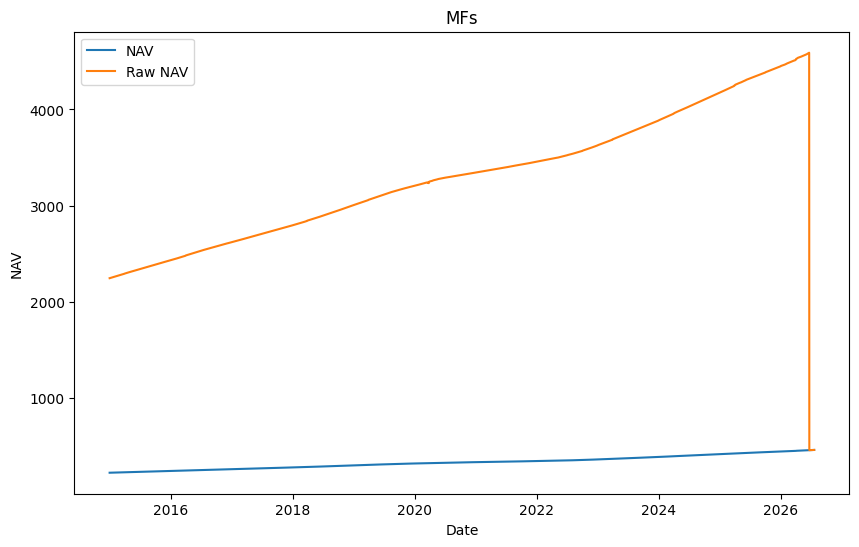

In [10]:
# Query
df = conn.execute(
    """
    SELECT sd_id, date, nav, raw_nav
    FROM nav
    WHERE sd_id = 120304
    ORDER BY date
    """
).pl()

# Plot with Matplotlib
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(df['date'].to_list(), df['nav'].to_list(), label='NAV')
ax.plot(df['date'].to_list(), df['raw_nav'].to_list(), label='Raw NAV')
ax.set_title('MFs')
ax.set_xlabel('Date')
ax.set_ylabel('NAV')
ax.legend()
plt.show()

In [11]:
# Duplicate plan -> scheme
conn.execute(
    """
    SELECT sd_id, COUNT(DISTINCT scheme_id) count
    FROM nav
    LEFT JOIN plans USING (sd_id)
    WHERE sd_id in (SELECT sd_id from plans)
    GROUP BY sd_id HAVING COUNT(DISTINCT scheme) <> 1
    ORDER BY count DESC
    """
).pl().show(100)

sd_id,count
i32,i64


In [12]:
# Funds which get 0 randomly inbetween
conn.execute(
    """
    WITH first_positive AS (
        -- Identify the start of the valid series for each sd_id
        SELECT sd_id, min(date) AS start_date
        FROM nav
        WHERE nav > 0
        GROUP BY sd_id
    )
    SELECT
        a.sd_id,
        f.start_date AS first_non_zero_date,
        count(CASE WHEN a.nav <= 0 THEN 1 END) AS count_non_positive_after_start,
        string_agg(
            CASE WHEN a.nav <= 0 THEN a.date::VARCHAR END, 
            ', ' ORDER BY a.date
        ) AS non_positive_dates
    FROM nav a
    JOIN first_positive f 
        ON a.sd_id = f.sd_id
    WHERE a.date > f.start_date
    GROUP BY a.sd_id, f.start_date HAVING count_non_positive_after_start > 0;
    """
).pl().show(100)

sd_id,first_non_zero_date,count_non_positive_after_start,non_positive_dates
i32,date,i64,str


In [13]:
# High oscilations
conn.execute(
    """
    WITH lagged_data AS (
        SELECT 
            sd_id, date, nav,
            LAG(nav) OVER (PARTITION BY sd_id ORDER BY date ASC) as prev_nav
            , CASE 
                WHEN prev_nav = 0 THEN NULL 
                ELSE (nav / prev_nav) - 1 
            END AS simple_return
        FROM nav
    )
    SELECT 
        scheme, sd_id
        , max(simple_return) max_ret, arg_max(date, simple_return) max_date
        , min(simple_return) min_ret, arg_min(date, simple_return) min_date
        , sum(CASE WHEN simple_return > 0.36 THEN 1 END) high_osc
        , sum(CASE WHEN simple_return < -0.36 THEN 1 END) low_osc
        , QUANTILE_CONT(simple_return, 0.95) pct_95
        , QUANTILE_CONT(simple_return, 0.05) pct_05
    FROM lagged_data
    LEFT JOIN plans ap USING (sd_id) 
    GROUP BY scheme, sd_id HAVING max_ret > 0.36 OR min_ret < -0.36
    ORDER BY scheme;
    """
).pl()
# 133868 and 138358 are okay

scheme,sd_id,max_ret,max_date,min_ret,min_date,high_osc,low_osc,pct_95,pct_05
str,i32,f64,date,f64,date,"decimal[38,0]","decimal[38,0]",f64,f64
"""BANK OF INDIA CREDIT RISK FUND""",133868,1.21837,2022-03-31,-0.502194,2020-04-24,1,1,0.001068,-0.000398
"""PGIM India Ultra Short Duration Fund""",138358,0.441974,2019-09-27,-0.302921,2019-09-13,1,null,0.000802,-0.000005


In [14]:
conn.execute(
    """
    SELECT *
    FROM plans
    WHERE TRUE
        -- AND sd_id in (151727)
        AND scheme ILIKE 'hsbc%equ%'
    """
).pl().show(25)

fund_house_id,fund_house,scheme_id,scheme,sd_id,plan,scheme_type,category,subcategory,tax,aum,launch_date,start_date,latest_date,latest_nav,is_in_use,is_not_lockin,is_retail,is_etf,is_growth,is_direct
i32,str,i32,str,i32,str,str,str,str,"decimal[4,3]",f64,date,date,date,f64,bool,bool,bool,bool,bool,bool
37,"""HSBC Mutual Fund""",13347,"""HSBC Equity Savings Fund""",151060,"""HSBC Equity Savings Fund - Dir…","""Open Ended""","""hybrid""","""equity savings""",0.125,76839.55,2011-09-27,2022-11-28,2026-07-17,41.0367,true,true,true,false,true,true


In [15]:
conn.execute(
    """
    SELECT *
    FROM nav
    WHERE TRUE
        AND sd_id in (120716)
        -- AND scheme ILIKE '%parag%'
    """
).pl()

sd_id,date,nav,raw_nav
i32,date,f64,f64
120716,2015-01-01,52.1199,52.1199
120716,2015-01-02,52.8108,52.8108
120716,2015-01-05,52.7041,52.7041
120716,2015-01-06,51.131,51.131
120716,2015-01-07,50.9729,50.9729
120716,2015-01-08,51.7978,51.7978
120716,2015-01-09,52.1094,52.1094
120716,2015-01-12,52.348,52.348
120716,2015-01-13,52.1996,52.1996


In [46]:
conn.execute(
    """
    WITH risk_unpivoted AS (
        SELECT 
            sd_id, 
            scheme, 
            val AS md_val
        FROM metrics_risk_monthly
        UNPIVOT (val FOR col IN (COLUMNS('^md_.*')))
        WHERE scheme ILIKE '%arbitrage%' AND scheme NOT ILIKE '%plus%'
    ),
    basic_unpivoted AS (
        SELECT 
            sd_id, 
            scheme, 
            val AS r_val
        FROM metrics_basic_monthly
        UNPIVOT (val FOR col IN (COLUMNS('^r_.*')))
        WHERE scheme ILIKE '%arbitrage%' AND scheme NOT ILIKE '%plus%'
    ),
    risk_summary AS (
        SELECT 
            scheme,
            MIN(md_val) AS max_drawdown
        FROM risk_unpivoted
        GROUP BY scheme
    ),
    basic_summary AS (
        SELECT 
            scheme,
            COUNT(r_val) AS total_non_null_months,
            COUNT(CASE WHEN r_val < 0 THEN 1 END) AS total_negative_return_months
        FROM basic_unpivoted
        GROUP BY scheme
    )
    SELECT 
        min(r.max_drawdown) max_monthly_drawdown,
        sum(b.total_non_null_months) total_month_across_funds,
        sum(b.total_negative_return_months) months_with_negative_returns
    FROM risk_summary r
    INNER JOIN basic_summary b USING (scheme)
    -- ORDER BY r.max_drawdown ASC;
    """
).pl()

max_monthly_drawdown,total_month_across_funds,months_with_negative_returns
f64,"decimal[38,0]","decimal[38,0]"
-0.749376,2895,3


In [30]:
# ALl
conn.execute(
    """
    SELECT p.sd_id, p.scheme, p.aum, start_date,
        category, subcategory,

        mby.r_2026, mby.r_2025, mby.r_2024, mby.r_2023, mby.r_2022, mby.r_2021, mby.r_2020,
        -- mry.md_2026, mry.md_2025, mry.md_2024, mry.md_2023, mry.md_2022, mry.md_2021, mry.md_2020,
        -- mry.ui_2026, mry.ui_2025, mry.ui_2024, mry.ui_2023, mry.ui_2022, mry.ui_2021, mry.ui_2020,

        mby.r_2026 + mby.r_2025 + mby.r_2024 + mby.r_2023 AS r
        , LEAST(mby.r_2026, mby.r_2025, mby.r_2024, mby.r_2023, mby.r_2022, mby.r_2021, mby.r_2020) least_r
        , greatest(mby.vol_2026, mby.vol_2025, mby.vol_2024, mby.vol_2023, mby.vol_2022, mby.vol_2021, mby.vol_2020) vol
        , LEAST(mry.md_2026, mry.md_2025, mry.md_2024, mry.md_2023, mry.md_2022, mry.md_2021, mry.md_2020) md
        , r_2020, sortino_2020
    FROM plans p
    INNER JOIN metrics_basic_yearly mby USING (sd_id, scheme)
    INNER JOIN metrics_risk_yearly mry USING (sd_id, scheme)
    INNER JOIN metrics_performance_yearly mpy USING (sd_id, scheme)
    INNER JOIN metrics_benchmark_yearly mpy USING (sd_id, scheme)
    INNER JOIN metrics_basic_monthly mbm USING (sd_id, scheme)
    INNER JOIN metrics_risk_monthly mrm USING (sd_id, scheme)
    INNER JOIN metrics_risk_quarterly mrq USING (sd_id, scheme)
    WHERE TRUE
        -- AND start_date < '2020-01-01'
        AND category in ('equity', 'hybrid', 'debt')
        AND subcategory not in ('credit risk', 'multi asset allocation')
        -- AND subcategory in ('equity savings')
        -- AND md_2026 >= -5 AND md_2025 >= -5 AND md_2024 >= -5 AND md_2023 >= -5 
        -- AND md_2022 >= -5 AND md_2021 >= -5 AND md_2020 >= -5
        AND md > -10
        and least_r > 0 
        AND r > 32
    ORDER BY vol;
    """
).pl()

sd_id,scheme,aum,start_date,category,subcategory,r_2026,r_2025,r_2024,r_2023,r_2022,r_2021,r_2020,r,least_r,vol,md,r_2020_1,sortino_2020
i32,str,f64,date,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
148958,"""Parag Parikh Conservative Hybrid Fund""",313700.14,2021-05-28,"""hybrid""","""conservative hybrid""",3.427846,7.660881,12.708335,13.813105,7.561146,4.289627,null,37.610168,3.427846,3.65634,-2.322675,null,null
150206,"""BARODA BNP PARIBAS CONSERVATIVE HYBRID FUND""",82884.43,2022-03-14,"""hybrid""","""conservative hybrid""",2.331397,6.760772,11.411611,12.580812,4.100537,null,null,33.084591,2.331397,4.711925,-4.495903,null,null
120616,"""ICICI Prudential Regular Savings Fund""",335982.81,2013-01-04,"""hybrid""","""conservative hybrid""",2.164481,8.511591,12.102224,12.015468,5.509227,10.824307,11.710266,34.793764,2.164481,6.289473,-8.849088,11.710266,0.974316
147496,"""Baroda BNP Paribas Equity Savings Fund""",27449.94,2019-07-30,"""hybrid""","""equity savings""",1.388896,7.78743,11.979994,14.432834,3.829537,7.731521,13.064361,35.589154,1.388896,7.65478,-8.42803,13.064361,1.072718
140347,"""Edelweiss Equity Savings Fund""",107132.99,2016-11-28,"""hybrid""","""equity savings""",3.842834,8.777351,14.35317,13.959592,4.175738,12.950437,13.960614,40.932947,3.842834,8.261582,-9.497305,13.960614,1.067992
152076,"""360 ONE Balanced Hybrid Fund""",85344.95,2023-10-03,"""hybrid""","""balanced hybrid""",3.869218,4.915488,17.733889,6.333028,null,null,null,32.851623,3.869218,8.947533,-6.617879,null,null
152132,"""WhiteOak Capital Balanced Hybrid Fund""",25257.71,2023-10-30,"""hybrid""","""balanced hybrid""",0.992266,7.857818,17.09101,7.671588,null,null,null,33.612683,0.992266,9.233665,-8.235294,null,null
150470,"""Mirae Asset Balanced Advantage Fund""",198472.77,2022-08-12,"""hybrid""","""dynamic asset allocation or balanced advantage""",1.229723,9.795889,12.556781,19.479763,2.515221,null,null,43.062156,1.229723,9.620339,-7.085388,null,null
151267,"""WhiteOak Capital Balanced Advantage Fund""",204497.53,2023-02-13,"""hybrid""","""dynamic asset allocation or balanced advantage""",1.085755,8.184251,18.622599,19.692555,null,null,null,47.58516,1.085755,10.857125,-9.541367,null,null


In [49]:
# ALl
conn.execute(
    """
    SELECT p.sd_id, p.scheme, p.aum, start_date,
        category, subcategory,

        mby.r_2026, mby.r_2025, mby.r_2024, mby.r_2023, mby.r_2022, mby.r_2021, mby.r_2020,
        mry.md_2026, mry.md_2025, mry.md_2024, mry.md_2023, mry.md_2022, mry.md_2021, mry.md_2020,
        mry.ui_2026, mry.ui_2025, mry.ui_2024, mry.ui_2023, mry.ui_2022, mry.ui_2021, mry.ui_2020,

        mby.r_2026 + mby.r_2025 + mby.r_2024 + mby.r_2023 AS r,
        mry.ui_2026 + mry.ui_2025 + mry.ui_2024 + mry.ui_2023 + mry.ui_2022 + mry.ui_2021 + mry.ui_2020 AS ui,
        mry.cvar95_2026 + mry.cvar95_2025 + mry.cvar95_2024 + mry.cvar95_2023 + mry.cvar95_2022 + mry.cvar95_2021 + mry.cvar95_2020 AS cvar95,

        -- 1. COVID-19 Stress Test (The 2020 Shock)
        mbm.r_2020_02, mbm.r_2020_03, mbm.r_2020_04, mbm.r_2020_05,
        mrm.md_2020_02, mrm.md_2020_03, mrm.md_2020_04, mrm.md_2020_05,
        LEAST(
            mbm.r_2020_01, mbm.r_2020_02, mbm.r_2020_03, mbm.r_2020_04, 
            mbm.r_2020_05, mbm.r_2020_06, mbm.r_2020_07, mbm.r_2020_08, 
            mbm.r_2020_09, mbm.r_2020_10, mbm.r_2020_11, mbm.r_2020_12
        ) AS worst_month_2020,

        -- 2. Ukraine War Stress Test (The 2022 Shock)
        mbm.r_2022_01, mbm.r_2022_02, mbm.r_2022_03, mbm.r_2022_04,
        mrm.md_2022_01, mrm.md_2022_02, mrm.md_2022_03, mrm.md_2022_04,
        LEAST(
            mbm.r_2022_01, mbm.r_2022_02, mbm.r_2022_03, mbm.r_2022_04, 
            mbm.r_2022_05, mbm.r_2022_06, mbm.r_2022_07, mbm.r_2022_08, 
            mbm.r_2022_09, mbm.r_2022_10, mbm.r_2022_11, mbm.r_2022_12
        ) AS worst_month_2022,

        -- 3. Tariff War Stress Test (The 2025 Shock)
        mbm.r_2025_03, mbm.r_2025_04, mbm.r_2025_05, mbm.r_2025_06,
        mrm.md_2025_03, mrm.md_2025_04, mrm.md_2025_05, mrm.md_2025_06,
        LEAST(
            mbm.r_2025_01, mbm.r_2025_02, mbm.r_2025_03, mbm.r_2025_04, 
            mbm.r_2025_05, mbm.r_2025_06, mbm.r_2025_07, mbm.r_2025_08, 
            mbm.r_2025_09, mbm.r_2025_10, mbm.r_2025_11, mbm.r_2025_12
        ) AS worst_month_2025,

        -- 4. Iran War Stress Test (The 2026 Shock)
        mbm.r_2026_02, mbm.r_2026_03, mbm.r_2026_04,
        mrm.md_2026_02, mrm.md_2026_03, mrm.md_2026_04,
        LEAST(
            mbm.r_2026_01, mbm.r_2026_02, mbm.r_2026_03, mbm.r_2026_04
        ) AS worst_month_2026,
    
        -- 5. Tail Risk: Expected Shortfall (CVaR)
        -- Tells us the average loss in the worst 5% of cases.
        mry.cvar95_2020 AS tail_risk_2020,
        mry.cvar95_2022 AS tail_risk_2022,
        mry.cvar95_2025 AS tail_risk_2025,
        mry.cvar95_2026 AS tail_risk_2026,
    
        -- 6. Current Efficiency
        mpy.sortino_2025 AS efficiency_2025,
        mby.r_2026 AS ytd_2026
    FROM plans p
    INNER JOIN metrics_basic_yearly mby USING (sd_id, scheme)
    INNER JOIN metrics_risk_yearly mry USING (sd_id, scheme)
    INNER JOIN metrics_performance_yearly mpy USING (sd_id, scheme)
    INNER JOIN metrics_basic_monthly mbm USING (sd_id, scheme)
    INNER JOIN metrics_risk_monthly mrm USING (sd_id, scheme)
    INNER JOIN metrics_risk_quarterly mrq USING (sd_id, scheme)
    
    WHERE TRUE
        AND (
            scheme ILIKE 'hdfc%' OR scheme ILIKE 'motilal%'
        )
        AND not (
            scheme ILIKE '%gold%' OR scheme ILIKE '%silver%' OR scheme ILIKE '%etf%'
        )
    
    ORDER BY r DESC;
    """
).pl()

sd_id,scheme,aum,start_date,category,subcategory,r_2026,r_2025,r_2024,r_2023,r_2022,r_2021,r_2020,md_2026,md_2025,md_2024,md_2023,md_2022,md_2021,md_2020,ui_2026,ui_2025,ui_2024,ui_2023,ui_2022,ui_2021,ui_2020,r,ui,cvar95,r_2020_02,r_2020_03,r_2020_04,r_2020_05,md_2020_02,md_2020_03,md_2020_04,md_2020_05,worst_month_2020,r_2022_01,r_2022_02,r_2022_03,r_2022_04,md_2022_01,md_2022_02,md_2022_03,md_2022_04,worst_month_2022,r_2025_03,r_2025_04,r_2025_05,r_2025_06,md_2025_03,md_2025_04,md_2025_05,md_2025_06,worst_month_2025,r_2026_02,r_2026_03,r_2026_04,md_2026_02,md_2026_03,md_2026_04,worst_month_2026,tail_risk_2020,tail_risk_2022,tail_risk_2025,tail_risk_2026,efficiency_2025,ytd_2026
i32,str,f64,date,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
145552,"""Motilal Oswal Nasdaq 100 Fund of Fund""",636682.61,2018-12-03,"""other""","""fof domestic""",41.815249,8.622473,55.270022,51.716711,-25.717939,28.366918,51.185963,-8.543062,-26.209708,-14.551649,-7.976919,-29.809778,-9.899283,-24.827209,3.500295,12.844816,3.864404,2.613481,20.247135,3.204788,6.126906,157.424456,52.401825,-21.402322,-5.590244,-3.499431,17.69143,8.053204,-11.826354,-20.172637,-4.525536,-2.816873,-6.322305,-10.509759,-5.510161,4.342571,-12.588353,-13.175793,-12.395374,-5.767324,-13.740583,-12.588353,-3.45857,-6.006812,5.351495,8.051258,-6.27458,-10.12493,-2.327901,-1.338561,-9.597851,-0.131505,3.856239,25.408348,-4.140647,-2.998365,-0.746485,-1.721023,-4.421824,-4.26286,-3.689446,-2.544669,0.197443,41.815249
151750,"""HDFC Defence Fund""",737216.73,2023-06-02,"""equity""","""sectoral/ thematic""",25.415608,9.775122,41.183732,53.02228,null,null,null,-14.272093,-25.259343,-19.269986,-8.185224,null,null,null,4.012284,9.859007,8.691278,2.511133,null,null,null,129.396741,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,20.463643,6.489119,18.76549,2.823732,-2.176415,-6.923153,-2.910919,-2.952252,-12.736024,5.271665,-11.640066,17.129846,-3.368472,-14.272093,-1.80887,-11.640066,null,null,-3.606644,-3.264922,0.362983,25.415608
150518,"""Motilal Oswal BSE Enhanced Value Index Fund""",110249.14,2022-08-26,"""other""","""index funds""",-2.987943,21.690811,19.085088,57.243605,16.164239,null,null,-17.264411,-10.976814,-14.464257,-9.002916,-9.79369,null,null,8.552463,3.976515,5.652059,3.08851,3.3429,null,null,95.031561,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,-3.986844,8.129913,2.835333,3.677434,2.946784,-2.79646,-6.862065,-3.862461,-5.084918,-4.10303,7.857938,-15.334324,8.509268,-2.303877,-15.334324,-1.921361,-15.334324,null,-2.809715,-2.66998,-3.121673,1.144485,-2.987943
148381,"""Motilal Oswal S&P 500 Index Fund""",405978.09,2020-04-29,"""other""","""index funds""",16.76988,22.300339,27.026449,25.689967,-9.583058,29.210668,25.531612,-6.358356,-19.374717,-7.881047,-9.015525,-19.761495,-4.257108,-8.959264,2.286702,5.160577,1.814265,2.820888,10.671862,1.425544,3.296048,91.786634,27.475887,-16.11466,null,null,null,6.768474,null,null,null,-3.843869,-3.611576,-6.515807,-2.076299,6.867318,-4.757421,-9.128093,-6.881417,-4.314964,-7.387347,-6.515807,-6.07601,-2.436519,5.363579,4.948084,-6.547292,-11.317574,-3.103307,-0.612384,-6.07601,-1.838282,-2.554772,11.340909,-3.790138,-5.07084,-0.183225,-2.554772,-3.025371,-3.219574,-2.636758,-2.034851,1.227034,16.76988
149180,"""HDFC Developed World Overseas Equity Passive FOF""",145419.01,2021-10-06,"""other""","""fof overseas""",18.365152,26.157502,22.420965,24.242111,-9.50471,7.085749,null,-4.887742,-18.114686,-7.218867,-9.022292,-19.232203,-3.550684,null,1.932976,3.925371,1.679988,2.952286,11.018327,1.214322,null,91.185729,null,null,null,null,null,null,null,null,null,null,null,-6.613189,-1.204462,5.989663,-5.420869,-9.010436

In [48]:
# Liquid
conn.execute(
    """
    SELECT sd_id, scheme, start_date, aum
        , (mby.r_2025 + mby.r_2024 + mby.r_2023) / 3 AS avg_3y_r
        -- , cvar99_2026, cvar99_2025, cvar99_2024
        , mby.r_2026, mby.r_2025, mby.r_2024, mby.r_2023
        , mry.md_2026, mry.md_2025, mry.md_2024, mry.md_2023
        -- , mpy.sharpe_2026, mpy.sharpe_2025
        -- , mpy.sortino_2026, mpy.sortino_2025
    FROM plans
    INNER JOIN metrics_basic_yearly mby USING (sd_id, scheme)
    INNER JOIN metrics_performance_yearly mpy USING (sd_id, scheme)
    INNER JOIN metrics_risk_yearly mry USING (sd_id, scheme)
    WHERE TRUE
        AND category = 'debt'
        -- AND subcategory = 'ultra short duration'
        AND aum > 250_00  -- Increased threshold for your 50L corpus
        AND start_date <= '2021-01-01' -- Ensure at least 5 years of track record
        AND md_2025 >= -2
        AND md_2024 >= -2
        AND md_2023 >= -2
        AND md_2022 >= -2
        AND md_2021 >= -2
    ORDER BY avg_3y_r DESC
    """
).pl().show(10)

sd_id,scheme,start_date,aum,avg_3y_r,r_2026,r_2025,r_2024,r_2023,md_2026,md_2025,md_2024,md_2023
i32,str,date,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
134387,"""Aditya Birla Sun Life Credit R…",2015-04-22,108120.38,11.656173,8.441968,14.327956,12.881788,7.758775,-0.382164,-0.310028,-0.28769,-0.194757
119539,"""Aditya Birla Sun Life Medium T…",2013-01-02,283379.31,10.19215,5.904491,11.706028,11.295416,7.575006,-0.612341,-0.392404,-0.369537,-0.491917
118780,"""Nippon India Credit Risk Fund …",2013-01-02,100644.05,9.138763,4.423974,9.742787,9.047483,8.626018,-0.372536,-0.290835,-0.10939,-0.132433
120711,"""ICICI Prudential Credit Risk F…",2013-01-03,593516.87,9.038875,4.321738,10.139839,9.089748,7.887037,-0.342159,-0.214364,-0.368015,-0.181386
128006,"""Kotak Medium Term Fund""",2014-03-25,204236.12,8.979855,3.803891,9.894496,9.985788,7.05928,-0.893372,-0.393915,-0.405587,-0.332595
120475,"""Axis Strategic Bond Fund""",2013-01-08,196281.46,8.789882,3.868709,8.937233,9.417677,8.014736,-0.663458,-0.363282,-0.277139,-0.443397
119798,"""SBI CREDIT RISK FUND""",2013-01-02,218747.13,8.764328,4.770291,8.613524,8.747958,8.931504,-0.350029,-0.26453,-0.502629,-0.150416
130314,"""Axis Credit Risk Fund""",2014-07-21,36646.85,8.743287,4.55149,9.573377,8.806031,7.850455,-0.419704,-0.208292,-0.170765,-0.161206
120670,"""ICICI Prudential Medium Term B…",2013-01-24,575982.48,8.679811,4.013732,9.647443,8.70334,7.68865,-0.572607,-0.330798,-0.281842,-0.374975


In [112]:
# Arbitrage
conn.execute(
    """
    SELECT p.sd_id, p.scheme, p.aum,

        mby.r_2026, mby.r_2025, mby.r_2024, mby.r_2023, mby.r_2022, mby.r_2021, mby.r_2020,
        mry.md_2026, mry.md_2025, mry.md_2024, mry.md_2023, mry.md_2022, mry.md_2021, mry.md_2020,
        mry.ui_2026, mry.ui_2025, mry.ui_2024, mry.ui_2023, mry.ui_2022, mry.ui_2021, mry.ui_2020,

        mby.r_2026 + mby.r_2025 + mby.r_2024 + mby.r_2023 + mby.r_2022 + mby.r_2021 + mby.r_2020 AS r,
        mry.ui_2026 + mry.ui_2025 + mry.ui_2024 + mry.ui_2023 + mry.ui_2022 + mry.ui_2021 + mry.ui_2020 AS ui,
        mry.cvar95_2026 + mry.cvar95_2025 + mry.cvar95_2024 + mry.cvar95_2023 + mry.cvar95_2022 + mry.cvar95_2021 + mry.cvar95_2020 AS cvar95,

        -- 1. COVID-19 Stress Test (The 2020 Shock)
        mbm.r_2020_02, mbm.r_2020_03, mbm.r_2020_04, mbm.r_2020_05,
        mrm.md_2020_02, mrm.md_2020_03, mrm.md_2020_04, mrm.md_2020_05,
        LEAST(
            mbm.r_2020_01, mbm.r_2020_02, mbm.r_2020_03, mbm.r_2020_04, 
            mbm.r_2020_05, mbm.r_2020_06, mbm.r_2020_07, mbm.r_2020_08, 
            mbm.r_2020_09, mbm.r_2020_10, mbm.r_2020_11, mbm.r_2020_12
        ) AS worst_month_2020,

        -- 2. Ukraine War Stress Test (The 2022 Shock)
        mbm.r_2022_01, mbm.r_2022_02, mbm.r_2022_03, mbm.r_2022_04,
        mrm.md_2022_01, mrm.md_2022_02, mrm.md_2022_03, mrm.md_2022_04,
        LEAST(
            mbm.r_2022_01, mbm.r_2022_02, mbm.r_2022_03, mbm.r_2022_04, 
            mbm.r_2022_05, mbm.r_2022_06, mbm.r_2022_07, mbm.r_2022_08, 
            mbm.r_2022_09, mbm.r_2022_10, mbm.r_2022_11, mbm.r_2022_12
        ) AS worst_month_2022,

        -- 3. Tariff War Stress Test (The 2025 Shock)
        mbm.r_2025_03, mbm.r_2025_04, mbm.r_2025_05, mbm.r_2025_06,
        mrm.md_2025_03, mrm.md_2025_04, mrm.md_2025_05, mrm.md_2025_06,
        LEAST(
            mbm.r_2025_01, mbm.r_2025_02, mbm.r_2025_03, mbm.r_2025_04, 
            mbm.r_2025_05, mbm.r_2025_06, mbm.r_2025_07, mbm.r_2025_08, 
            mbm.r_2025_09, mbm.r_2025_10, mbm.r_2025_11, mbm.r_2025_12
        ) AS worst_month_2025,

        -- 4. Iran War Stress Test (The 2026 Shock)
        mbm.r_2026_02, mbm.r_2026_03, mbm.r_2026_04,
        mrm.md_2026_02, mrm.md_2026_03, mrm.md_2026_04,
        LEAST(
            mbm.r_2026_01, mbm.r_2026_02, mbm.r_2026_03, mbm.r_2026_04
        ) AS worst_month_2026,
    
        -- 5. Tail Risk: Expected Shortfall (CVaR)
        -- Tells us the average loss in the worst 5% of cases.
        mry.cvar95_2020 AS tail_risk_2020,
        mry.cvar95_2022 AS tail_risk_2022,
        mry.cvar95_2025 AS tail_risk_2025,
        mry.cvar95_2026 AS tail_risk_2026,
    
        -- 6. Current Efficiency
        mpy.sortino_2025 AS efficiency_2025,
        mby.r_2026 AS ytd_2026
    FROM plans p
    INNER JOIN metrics_basic_yearly mby USING (sd_id, scheme)
    INNER JOIN metrics_risk_yearly mry USING (sd_id, scheme)
    INNER JOIN metrics_performance_yearly mpy USING (sd_id, scheme)
    INNER JOIN metrics_basic_monthly mbm USING (sd_id, scheme)
    INNER JOIN metrics_risk_monthly mrm USING (sd_id, scheme)
    INNER JOIN metrics_risk_quarterly mrq USING (sd_id, scheme)
    
    WHERE 
        p.category = 'hybrid' 
        AND p.scheme ILIKE '%arbitrage%'
        -- AND p.aum > 5000_00
        -- AND p.start_date <= '2020-01-01'
    
    ORDER BY mry.md_2026 + mry.md_2025 + mry.md_2024 + mry.md_2023 + mry.md_2022 + mry.md_2021 + mry.md_2020 ASC;
    """
).pl().show(100)

sd_id,scheme,aum,r_2026,r_2025,r_2024,r_2023,r_2022,r_2021,r_2020,md_2026,md_2025,md_2024,md_2023,md_2022,md_2021,md_2020,ui_2026,ui_2025,ui_2024,ui_2023,ui_2022,ui_2021,ui_2020,r,ui,cvar95,r_2020_02,r_2020_03,r_2020_04,r_2020_05,md_2020_02,md_2020_03,md_2020_04,md_2020_05,worst_month_2020,r_2022_01,r_2022_02,r_2022_03,r_2022_04,md_2022_01,md_2022_02,md_2022_03,md_2022_04,worst_month_2022,r_2025_03,r_2025_04,r_2025_05,r_2025_06,md_2025_03,md_2025_04,md_2025_05,md_2025_06,worst_month_2025,r_2026_02,r_2026_03,r_2026_04,md_2026_02,md_2026_03,md_2026_04,worst_month_2026,tail_risk_2020,tail_risk_2022,tail_risk_2025,tail_risk_2026,efficiency_2025,ytd_2026
i32,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
143614,"""BANK OF INDIA ARBITRAGE FUND""",4267.41,1.917679,6.390432,7.611208,6.765843,3.402029,2.859052,3.847909,-0.124809,-0.239318,-0.16662,-0.223981,-0.190941,-0.218745,-0.587764,0.030512,0.032991,0.035122,0.031374,0.054474,0.05293,0.124196,32.794152,0.361599,-0.744632,0.58148,0.310975,0.387394,0.631679,-0.081591,-0.587764,-0.23873,-0.106711,0.106741,0.266692,0.31703,0.033144,0.252234,-0.115116,-0.091035,-0.131663,-0.098222,0.033144,0.646861,0.729999,0.28586,0.487423,-0.089931,-0.140176,-0.239318,-0.09536,0.28586,0.44205,0.492354,0.398825,-0.071496,-0.081305,-0.07608,0.398825,-0.171458,-0.089741,-0.091692,-0.078528,-1.477451,1.917679
146297,"""Union Arbitrage Fund""",28621.33,1.961662,6.605259,8.156313,7.540393,4.257639,4.169222,4.912141,-0.091792,-0.258086,-0.176691,-0.170875,-0.224921,-0.179107,-0.59075,0.026731,0.030507,0.035038,0.027623,0.049016,0.047287,0.158684,37.602629,0.374886,-0.733589,0.679716,0.613589,0.542913,0.920302,-0.058039,-0.59075,-0.246785,-0.160327,0.210126,0.353073,0.513312,0.18638,0.144832,-0.136449,-0.070499,-0.078937,-0.202115,0.101308,0.662424,0.670361,0.359947,0.522582,-0.084984,-0.133449,-0.258086,-0.056572,0.283174,0.449822,0.540015,0.392742,-0.078739,-0.091792,-0.072684,0.392742,-0.198322,-0.094471,-0.083977,-0.069192,-1.205533,1.961662
118474,"""BANDHAN Arbitrage Fund""",891384.39,1.99657,6.966234,8.191632,7.812883,4.792295,4.28517,4.530881,-0.087032,-0.243502,-0.149828,-0.15239,-0.122551,-0.1669,-0.749376,0.025754,0.027487,0.030405,0.025738,0.036218,0.043205,0.176843,38.575664,0.36565,-0.690605,0.648911,0.3287,0.493206,0.853349,-0.068359,-0.749376,-0.221146,-0.111541,0.183078,0.37952,0.472936,0.165068,0.357813,-0.116205,-0.069005,-0.090029,-0.112738,0.11563,0.726184,0.764693,0.388183,0.530861,-0.081226,-0.110475,-0.243502,-0.076768,0.302138,0.492906,0.501478,0.441147,-0.050312,-0.087032,-0.080898,0.441147,-0.188512,-0.086553,-0.077391,-0.068824,-0.524732,1.99657
147617,"""ITI Arbitrage Fund""",4966.36,2.20094,7.258578,7.942047,7.135557,3.232644,3.19569,3.749055,-0.115575,-0.284601,-0.166981,-0.146867,-0.175877,-0.187944,-0.578141,0.028655,0.037455,0.037789,0.031272,0.058326,0.062095,0.172646,34.714511,0.428238,-0.786404,0.622621,0.025256,0.504889,0.742801,-0.065214,-0.475661,-0.175697,-0.114781,0.019013,0.312896,0.37778,-0.010028,0.215093,-0.131821,-0.121484,-0.166779,-0.108372,-0.010028,0.739775,0.807726,0.408392,0.591694,-0.098159,-0.148587,-0.284601,-0.050282,0.34568,0.543281,0.70922,0.330246,-0.115575,-0.05507,-0.060193,0.330246,-0.185105,-0.091385,-0.097995,-0.085393,0.41508,2.20094
118931,"""HDFC Arbitrage Fund""",2.3255e6,2.031596,6.870625,8.157682,7.714988,4.679891,4.219131,4.218629,-0.08611,-0.230211,-0.141579,-0.134168,-0.147367,-0.173039,-0.728937,0.024931,0.029046,0.0306,0.026505,0.038159,0.042338,0.170448,37.892541,0.362026,-0.714726,0.606501,0.323157,0.394185,0.734518,-0.05963,-0.728937,-0.26696,-0.126433,0.141155,0.364255,0.449793,0.157152,0.349006,-0.13426,-0.074697,-0.086396,-0.129295,0.108713,0.698427,0.751329,0.337902,0.54729,-0.076692,-0.091645,-0.230211,-0.087772,

In [74]:
# N50
indexes = (
    # -- N50
    120716, 119063, 120620,
    119288, 119648, 148978, 120307, 118881, 146376, 147794, 149373, 118581, 151157,
    # -- Cheap N50
    149039, 149250,
)
conn.execute(
    f"""
    SELECT 
        p.sd_id, p.scheme, p.aum, p.start_date,
        
        -- 1. Realized Returns (The "Bottom Line")
        mby.r_2026, mby.r_2025, mby.r_2024, mby.r_2023, mby.r_2022, mby.r_2021, mby.r_2020,
        (mby.r_2025 + mby.r_2024 + mby.r_2023) / 3 AS avg_3y_r,
    
        -- 2. Risk Profile (Worst Case & Recovery)
        mry.md_2020 AS crash_dd_2020,
        mry.md_2026 AS current_shock_dd,
        mry.ui_2025 AS misery_index_2025,
        mry.ui_2020 AS misery_index_2020,
    
        -- 3. Efficiency Metrics
        mpy.sortino_2025 AS efficiency_2025,
        mpy.sharpe_2025 AS reward_to_vol_2025
    
    FROM plans p
    INNER JOIN metrics_basic_yearly mby USING (sd_id, scheme)
    INNER JOIN metrics_risk_yearly mry USING (sd_id, scheme)
    INNER JOIN metrics_performance_yearly mpy USING (sd_id, scheme)
    
    WHERE TRUE
       AND sd_id IN {str(indexes)}    
    ORDER BY avg_3y_r DESC;
    """
).pl().write_csv("n50.csv")

In [83]:
# M150
indexes = (
    147622, 148726, 150673,
    149389, 150428, 151724, 148807, 149892,
    152916, 150313, 153581, 153788, 153089,
    152855, 153401, 153000, 153939, 154014
)
conn.execute(
    f"""
    SELECT 
        p.sd_id, p.scheme, p.aum, p.start_date,
        
        -- 1. The Bottom Line (Realized Returns)
        mby.r_2026, mby.r_2025, mby.r_2024, mby.r_2023,
        (mby.r_2025 + mby.r_2024 + mby.r_2023) / 3 AS avg_3y_r,
    
        -- 2. Volatility Analysis (Midcap specific)
        mby.vol_2025, mby.vol_2024,
        
        -- 3. Resilience to 2026 Iran Shock
        mry.md_2026 AS shock_dd_2026,
        mry.ui_2026 AS misery_2026,
    
        -- 4. Risk-Adjusted Returns
        mpy.sortino_2025 AS efficiency_2025
    
    FROM plans p
    INNER JOIN metrics_basic_yearly mby USING (sd_id, scheme)
    INNER JOIN metrics_risk_yearly mry USING (sd_id, scheme)
    INNER JOIN metrics_performance_yearly mpy USING (sd_id, scheme)
    
    WHERE TRUE
       AND sd_id IN {str(indexes)}    
    ORDER BY avg_3y_r DESC;
    """
).pl()

sd_id,scheme,aum,start_date,r_2026,r_2025,r_2024,r_2023,avg_3y_r,vol_2025,vol_2024,shock_dd_2026,misery_2026,efficiency_2025
i32,str,f64,date,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
151724,"""HDFC NIFTY Midcap 150 Index Fund""",45238.36,2023-04-21,-2.18597,5.017578,23.117434,45.577707,24.570906,17.194825,17.515503,-13.977507,6.515865,-0.00356
147622,"""Motilal Oswal Nifty Midcap 150 Index Fund""",286875.69,2019-09-11,-2.078389,5.281905,23.488625,43.284621,24.018384,17.209994,17.543733,-13.927441,6.473075,0.016985
148807,"""Aditya Birla Sun Life Nifty Midcap 150 Index Fund""",41200.3,2021-04-06,-2.130222,4.928781,23.711955,43.14074,23.927159,17.20603,17.541084,-13.97758,6.502158,-0.010427
148726,"""Nippon India Nifty Midcap 150 Index Fund""",206837.84,2021-02-23,-2.111515,5.099274,23.136625,43.030955,23.755618,17.177422,17.528856,-13.931912,6.482938,0.001546
150673,"""SBI Nifty Midcap 150 Index Fund""",94289.09,2022-10-11,-2.142299,4.997099,23.182968,42.895998,23.692022,17.111741,17.441457,-13.976399,6.457153,-0.011426
149389,"""ICICI Prudential Nifty Midcap 150 Index Fund""",92499.64,2021-12-23,-2.111565,5.057525,23.090601,42.762213,23.63678,17.203424,17.514108,-13.939136,6.487846,-0.000378
149892,"""Navi Nifty Midcap 150 Index Fund""",34972.51,2022-03-11,-2.148056,4.86589,23.238659,42.743942,23.616164,17.190544,17.506735,-13.970217,6.502822,-0.015254
150428,"""DSP Nifty Midcap 150 Quality 50 Index Fund""",48012.97,2022-08-04,-3.813629,-1.110602,19.417045,28.170228,15.492224,16.081346,14.924495,-14.378454,6.76899,-0.556231
150313,"""UTI Nifty Midcap 150 Quality 50 Index Fund""",25820.84,2022-04-13,-3.865694,-1.318872,19.39232,27.80155,15.291666,16.097487,14.929312,-14.429631,6.803796,-0.573324


In [93]:
# S250
indexes = (
    147623, 148519, 149283,
    150677, 150892, 151727, 151814,
    152156, 152264,
    152431, 152482, 152889, 152976,
    153223, 153790
)
conn.execute(
    f"""
    SELECT 
        p.sd_id, p.scheme, p.aum, p.start_date,
        
        -- 1. The Bottom Line (Realized Returns)
        mby.r_2026, mby.r_2025, mby.r_2024, mby.r_2023,
        (mby.r_2025 + mby.r_2024 + mby.r_2023) / 3 AS avg_3y_r,
    
        -- 2. Volatility Analysis (Midcap specific)
        mby.vol_2025, mby.vol_2024,
        
        -- 3. Resilience to 2026 Iran Shock
        mry.md_2026 AS shock_dd_2026,
        mry.ui_2026 AS misery_2026,
    
        -- 4. Risk-Adjusted Returns
        mpy.sortino_2025 AS efficiency_2025
    
    FROM plans p
    INNER JOIN metrics_basic_yearly mby USING (sd_id, scheme)
    INNER JOIN metrics_risk_yearly mry USING (sd_id, scheme)
    INNER JOIN metrics_performance_yearly mpy USING (sd_id, scheme)
    
    WHERE TRUE
       AND sd_id IN {str(indexes)}    
    ORDER BY avg_3y_r DESC;
    """
).pl().write_csv("s250.csv")

In [17]:
indexes = (
    # -- N50
    # 120716, 119063, 120620,
    # 119288, 119648, 148978, 120307, 118881, 146376, 147794, 149373, 118581, 148962, 151157
    # -- Cheap N50
    149039, # 149250, 112351,
    # -- NN50
    # 120684, # 143341, 150477,
    # # -- Cheap NN50
    # 150899, 148745, 153789, 149447,
    # # -- N50 EQ
    # 150639, 151762,149107,
    # # -- Cheap N50 EQ
    # 153150,
    # N100
    # 149868,
    # -- N100 EQ
    # 149870,# 153146
    # Mid150
    # 151724, 153089, 149389,
    # Cheap Mid150
    # 153581
    # 140088,
    # 149758,
    # 140107,
    # 119568,
    # 120389,
    # 101165,
    # 120711
)
conn.execute(
    f"""
    SELECT sd_id, scheme, start_date, aum
        , mby.r_2026, mby.vol_2026, mry.md_2026, mbky.alpha_2026, mpy.sharpe_2026, mpy.sortino_2026
        , mby.r_2025, mby.vol_2025, mry.md_2025, mbky.alpha_2025, mpy.sharpe_2025, mpy.sortino_2025
        , mby.r_2024, mby.vol_2024, mry.md_2024, mbky.alpha_2024, mpy.sharpe_2024, mpy.sortino_2024
        , mby.r_2023, mby.vol_2023, mry.md_2023, mbky.alpha_2023, mpy.sharpe_2023, mpy.sortino_2023
    FROM plans
    INNER JOIN metrics_basic_yearly mby USING (sd_id, scheme)
    INNER JOIN metrics_benchmark_yearly mbky USING (sd_id, scheme)
    INNER JOIN metrics_performance_yearly mpy USING (sd_id, scheme)
    INNER JOIN metrics_risk_yearly mry USING (sd_id, scheme)
    WHERE TRUE
        --AND aum > 100_00
        AND start_date <= '2026-01-01'
        AND (
            sd_id in {str(indexes)}
            OR sd_id > 9000000
        )
    """
).pl()
# conn.execute(
#     """
#     WITH weights AS (
#         -- Input your mapping here
#         SELECT 149870 AS sd_id, 30000 AS weight UNION ALL
#         SELECT 151724 AS sd_id, 40000 AS weight UNION ALL
#         SELECT 151727 AS sd_id, 30000 AS weight          
#     ),
#     common_start AS (
#         -- Find the earliest date where ALL funds have data to ensure a clean start
#         SELECT MAX(min_date) as start_date
#         FROM (SELECT sd_id, MIN(date) as min_date FROM nav GROUP BY sd_id)
#         WHERE sd_id IN (SELECT sd_id FROM weights)
#     ),
#     units_calc AS (
#         -- Calculate units bought on day 1: Weight / NAV_at_start
#         SELECT 
#             w.sd_id,
#             w.weight / r.nav AS units
#         FROM weights w
#         JOIN nav r ON w.sd_id = r.sd_id
#         WHERE r.date = (SELECT start_date FROM common_start)
#     )
#     -- Aggregate daily value: Sum(Units * Daily_NAV)
#     SELECT 
#         (random() * 1000000)::INT AS sd_id, -- User requested random ID
#         r.date,
#         SUM(u.units * r.nav) AS nav
#     FROM nav r
#     JOIN units_calc u ON r.sd_id = u.sd_id
#     WHERE r.date >= (SELECT start_date FROM common_start)
#     GROUP BY r.date
#     ORDER BY r.date;
#     """
# ).pl()

sd_id,scheme,start_date,aum,r_2026,vol_2026,md_2026,alpha_2026,sharpe_2026,sortino_2026,r_2025,vol_2025,md_2025,alpha_2025,sharpe_2025,sortino_2025,r_2024,vol_2024,md_2024,alpha_2024,sharpe_2024,sortino_2024,r_2023,vol_2023,md_2023,alpha_2023,sharpe_2023,sortino_2023
i32,str,date,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
120684,"""ICICI Prudential Nifty Next 50 Index Fund""",2013-01-02,582335.6,0.504045,23.589407,-14.416242,0.108003,-0.068127,-0.108875,2.075481,17.296406,-17.441522,-0.098767,-0.27829,-0.426386,27.370334,20.197448,-14.174088,0.170669,1.016812,1.47782,26.625798,12.333503,-12.741533,0.074531,1.609277,2.442326
149039,"""Navi Nifty 50 Index Fund""",2021-07-16,366889.35,-8.502353,18.704483,-15.101986,0.000322,-0.567429,-0.912196,11.272834,11.822784,-8.505778,0.000585,0.370805,0.668364,9.750261,13.985393,-10.816147,0.000079,0.20857,0.318214,20.479431,9.745905,-7.010437,0.000521,1.405888,2.526456
149868,"""HDFC NIFTY 100 Index Fund""",2022-02-23,22189.95,-7.032343,19.263731,-14.966897,0.017856,-0.474646,-0.762722,9.425621,12.292407,-10.021248,-0.019118,0.206366,0.358929,12.309837,14.570612,-11.37893,0.024791,0.37586,0.556455,20.30365,9.739467,-8.573086,0.000314,1.388769,2.409009
149870,"""HDFC NIFTY 100 Equal Weight Index Fund""",2022-02-23,28011.5,-1.384205,21.277025,-13.545198,0.081075,-0.164277,-0.26021,8.492971,14.350494,-12.429256,-0.031029,0.111779,0.181423,16.472306,16.11871,-13.997911,0.065863,0.597999,0.868073,29.493035,10.366507,-9.623571,0.105193,2.191216,3.595951
9000001,"""Akash""",2014-06-30,1.3049e6,-5.829322,15.815613,-12.51707,0.008396,-0.502063,-0.796398,8.747763,10.742235,-11.151216,-0.01754,0.173044,0.287248,22.998299,12.089597,-7.227753,0.138608,1.337097,1.962278,37.118993,8.098024,-4.536308,0.205981,3.746743,6.463005
9000002,"""Swathi""",2021-01-19,63357.76,-3.810379,14.424995,-10.488605,0.024733,-0.406651,-0.675745,8.925372,9.533668,-8.176871,0.004065,0.236919,0.404484,23.655781,12.005734,-6.374717,0.142802,1.41277,2.091437,35.826048,8.179492,-4.397251,0.191857,3.575126,6.548446
9000003,"""Mom""",2022-02-04,3335.93,20.882983,43.472592,-20.276646,0.274183,0.433726,0.699141,70.987953,13.899506,-9.278813,0.633167,4.619601,9.36149,16.006529,11.359359,-6.57081,0.085119,0.819772,1.311521,12.169636,9.137835,-5.390161,0.035735,0.599178,1.061653
9000004,"""HDFC All Cap Conservative""",2023-04-21,28011.5,-1.682524,21.989594,-13.988261,0.079999,-0.17252,-0.276263,3.983152,15.842363,-16.316106,-0.077882,-0.183416,-0.286703,20.427789,16.826611,-11.629006,0.106082,0.807914,1.150186,42.660919,10.292417,-6.442725,0.209382,3.683384,5.717723
9000005,"""HDFC All Cap Aggressive""",2023-04-21,28011.5,-1.784023,22.36792,-14.178781,0.079695,-0.174139,-0.281642,2.115624,16.590591,-17.851504,-0.09724,-0.287709,-0.445155,21.963665,17.36988,-11.031313,0.121678,0.871067,1.236514,45.217662,10.62257,-6.561397,0.239431,3.809592,5.717838


In [18]:
conn.execute(
    """
    CREATE OR REPLACE MACRO tax_adj(val, tax_rate) AS 
        CASE 
            WHEN val > 0 THEN val * (1 - tax_rate)
            ELSE val 
        END;
    """
)

pl.Config(tbl_rows=100)


conn.execute(
    """
    SELECT sd_id, y.scheme, category, subcategory, tax
        , tax_adj(cagr, tax) cagr
        , tax_adj(y_2026, tax) y_2026
        , tax_adj(y_2025, tax) y_2025
        , tax_adj(y_2024, tax) y_2024
        , tax_adj(y_2023, tax) y_2023
        , tax_adj(y_2022, tax) y_2022
        , tax_adj(y_2021, tax) y_2021
        , tax_adj(y_2020, tax) y_2020
        , tax_adj(q_2026_1, tax) q_2026_1
        , tax_adj(q_2025_4, tax) q_2025_4
        , tax_adj(q_2025_3, tax) q_2025_3
        , tax_adj(q_2025_2, tax) q_2025_2
        , tax_adj(q_2025_1, tax) q_2025_1
        , tax_adj(m_2026_03, tax) m_2026_03
        , tax_adj(m_2026_02, tax) m_2026_02
        , tax_adj(m_2026_01, tax) m_2026_01
        , tax_adj(m_2025_12, tax) m_2025_12
        , tax_adj(m_2025_11, tax) m_2025_11
        , tax_adj(m_2025_10, tax) m_2025_10
        , tax_adj(m_2025_09, tax) m_2025_09

    FROM returns_yearly y
    LEFT JOIN returns_quarterly q USING (sd_id)
    LEFT JOIN returns_monthly m USING (sd_id)
    LEFT JOIN plans USING (sd_id)
    WHERE TRUE
        AND category not in ('other', 'elss')
        -- AND y_2026 + y_2025 + y_2024  > 36
        AND y.scheme ILIKE '%parag%liq%'
        
    ORDER BY y_2025 + y_2024 DESC
    """
).pl()

CatalogException: Catalog Error: Table with name returns_yearly does not exist!
Did you mean "metrics_risk_yearly"?

LINE 24:     FROM returns_yearly y
                  ^

In [ ]:
DEBT_IDS = (
    # Credit Risk
    134387,
)
# Debt funds
conn.execute(
    f"""
    SELECT sd_id, scheme, subcategory, start_date, aum
        , mby.r_2026, mby.r_2025, mby.r_2024, mby.r_2023,  mby.r_2022
        , mry.md_2026, mry.md_2025, mry.md_2024, mry.md_2023
        , mby.vol_2026, mby.vol_2025, mby.vol_2024, mby.vol_2023
        , mpy.sharpe_2026, mpy.sharpe_2025, mpy.sharpe_2024, mpy.sharpe_2023
        , mpy.sortino_2026, mpy.sortino_2025, mpy.sortino_2024, mpy.sortino_2023
    FROM plans
    INNER JOIN metrics_basic_yearly mby USING (sd_id, scheme)
    INNER JOIN metrics_benchmark_yearly mbky USING (sd_id, scheme)
    INNER JOIN metrics_performance_yearly mpy USING (sd_id, scheme)
    INNER JOIN metrics_risk_yearly mry USING (sd_id, scheme)
    WHERE TRUE
        AND category = 'debt'
        AND subcategory <> 'credit risk'
        AND start_date <= '2026-01-01'
        AND r_2025 > 8
        AND r_2025 + r_2024 > 16
        AND r_2025 + r_2024 + r_2023 > 24
        AND sharpe_2025 > 1.2 AND sharpe_2024 > 1.2 AND sharpe_2023 > 1.2
    ORDER BY sharpe_2026 + sharpe_2025 + sharpe_2024 DESC
    """
).pl()

In [96]:
conn.execute(
    f"""
    WITH bench AS (
        SELECT *
        FROM quant_yearly
        WHERE sd_id = 149039
    )
    SELECT y.sd_id, y.scheme

        , r.y_2025
        , r.y_2024
        , r.y_2023
        , r.y_2022
        , r.y_2021
        , r.y_2020

        , b.md_2025 - y.md_2025 d_md_2025
        , b.md_2024 - y.md_2024 d_md_2024
        , b.md_2023 - y.md_2023 d_md_2023
        , b.md_2022 - y.md_2022 d_md_2022
        , b.md_2021 - y.md_2021 d_md_2021
        , b.md_2020 - y.md_2020 d_md_2020

        , y.a_2025, y.a_2024, y.a_2023, y.a_2022, y.a_2021, y.a_2020

        , y.so_2025 - b.so_2025 d_so_2025
        , y.so_2024 - b.so_2024 d_so_2024
        , y.so_2023 - b.so_2023 d_so_2023
        , y.so_2022 - b.so_2022 d_so_2022
        , y.so_2021 - b.so_2021 d_so_2021
        , y.so_2020 - b.so_2020 d_so_2020

    FROM quant_yearly y
    LEFT JOIN returns_yearly r USING (sd_id)
    LEFT JOIN plans p USING (sd_id)
    CROSS JOIN bench b
    LEFT JOIN returns_yearly ry ON b.sd_id = ry.sd_id
    WHERE TRUE
        -- AND y.md_2025 > -2 AND y.md_2024 > -1 AND y.md_2023 > -1
        AND d_md_2025 < 1 AND d_md_2024 < 1 AND d_md_2023 < 1
        AND y.a_2024 > 0.05 AND y.a_2023 > 0.05
        AND tax_adj(r.y_2025, tax) > 10 AND tax_adj(r.y_2024, tax) > 10 AND tax_adj(r.y_2023, tax) > 10
    ORDER BY y.a_2023 + y.a_2022 DESC
    --ORDER BY y_2025 + y_2024 DESC
    """
).pl()

sd_id,scheme,y_2025,y_2024,y_2023,y_2022,y_2021,y_2020,d_md_2025,d_md_2024,d_md_2023,d_md_2022,d_md_2021,d_md_2020,a_2025,a_2024,a_2023,a_2022,a_2021,a_2020,d_so_2025,d_so_2024,d_so_2023,d_so_2022,d_so_2021,d_so_2020
i32,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
145897,"""ICICI Prudential India Opportunities Fund""",13.520198,22.696477,36.700649,19.397993,50.553191,8.542247,-0.638171,-1.512639,-1.185195,-3.067894,null,null,0.028445,0.139304,0.201765,0.150188,null,null,0.313301,1.799813,3.428707,1.423221,null,null
129312,"""ICICI Prudential Dividend Yield Equity Fund""",12.694633,22.4476,39.936809,9.88819,47.966632,14.930765,0.01214,0.030019,-2.745882,-1.960746,null,null,0.019586,0.129222,0.228198,0.056629,null,null,0.202515,1.204414,4.204595,0.541196,null,null
118950,"""HDFC Focused Fund""",11.676803,25.399515,30.781242,18.178099,41.101271,4.729673,-0.873073,-3.891163,-2.205962,-4.426565,null,null,0.014283,0.165695,0.135961,0.140072,null,null,0.17105,2.036286,2.343866,1.308137,null,null
118955,"""HDFC Flexi Cap Fund""",11.77568,24.248053,30.669438,17.287922,36.170054,6.613401,-0.175538,-3.526285,-1.045232,-3.058157,null,null,0.012837,0.151852,0.12228,0.13229,null,null,0.152446,1.75011,1.869862,1.160872,null,null
120323,"""ICICI Prudential Value Fund (erstwhile Value Discovery Fund)""",13.912394,20.528522,31.152186,14.62422,37.915895,23.026878,-0.649175,-1.637846,-2.173775,-2.683124,null,null,0.034644,0.115401,0.141529,0.102064,null,null,0.495741,1.412313,2.734646,1.050424,null,null
120334,"""ICICI Prudential Multi-Asset Fund""",19.001417,16.900717,24.174202,16.628712,35.02795,10.415283,-5.106036,-5.289705,-4.613228,-7.284956,null,null,0.103496,0.090286,0.107501,0.117094,null,null,2.500342,1.680081,3.115966,1.724223,null,null
148651,"""ICICI Prudential Business Cycle Fund""",16.177097,21.077162,33.541234,10.5547,28.171828,null,-0.502408,-1.956876,-0.833361,-3.979255,null,null,0.054217,0.119846,0.155316,0.062712,null,null,0.704281,1.306053,2.665559,0.63231,null,null
120596,"""ICICI Prudential Large & Mid Cap Fund""",14.601332,21.079412,30.009879,11.112647,41.602144,12.15074,-0.659394,-0.095512,-0.908193,-2.030754,null,null,0.038226,0.11928,0.126065,0.070554,null,null,0.38903,1.217961,2.002865,0.616821,null,null
120251,"""ICICI Prudential Equity & Debt Fund""",13.431059,17.92023,28.084306,11.120936,41.914829,9.359051,-2.710415,-2.50609,-3.474438,-5.068089,null,null,0.036678,0.092481,0.129143,0.064546,null,null,0.595492,1.190585,3.041548,0.799799,null,null


In [108]:
conn.execute(
    f"""
    SELECT *
    FROM plans
    WHERE 
    scheme ILIKE '%nifty%100%index%'
    -- sd_id = 151762
    ORDER BY aum DESC
    """
).pl()
# NN50
# 120684, 143341, 150477
# 150899, 148745, 153789, 149447
# N50 EQ
# 150639, 151762,149107
# 153150
# N100 EQ
# 153146, 149870

fund_house_id,fund_house,scheme_id,scheme,sd_id,plan,scheme_type,category,subcategory,tax,aum,launch_date,start_date,latest_date,latest_nav,is_in_use,is_not_lockin,is_retail,is_etf,is_growth,is_direct
i32,str,i32,str,i32,str,str,str,str,"decimal[4,3]",f64,date,date,date,f64,bool,bool,bool,bool,bool,bool
48,"""Bandhan Mutual Fund""",13155,"""BANDHAN Nifty100 Low Volatility 30 Index Fund""",150636,"""BANDHAN NIFTY100 LOW VOLATILITY 30 INDEX FUND - GROWTH - DIRECT PLAN""","""Open Ended""","""other""","""index funds""",0.125,160612.11,2022-09-15,2022-10-07,2026-04-13,15.2078,true,true,true,false,true,true
53,"""Axis Mutual Fund""",12029,"""Axis Nifty 100 Index Fund""",147666,"""Axis Nifty 100 Index Fund - Direct Plan - Growth Option""","""Open Ended""","""other""","""index funds""",0.125,139584.58,2019-09-27,2019-10-23,2026-04-13,21.933,true,true,true,false,true,true
9,"""HDFC Mutual Fund""",12721,"""HDFC NIFTY 100 Equal Weight Index Fund""",149870,"""HDFC Nifty 100 Equal Weight Index Fund - Direct Plan - Growth Option""","""Open Ended""","""other""","""index funds""",0.125,28011.5,2022-02-11,2022-02-23,2026-04-13,16.4922,true,true,true,false,true,true
9,"""HDFC Mutual Fund""",12720,"""HDFC NIFTY 100 Index Fund""",149868,"""HDFC NIFTY 100 Index Fund - Direct Plan - Growth Option""","""Open Ended""","""other""","""index funds""",0.125,22189.95,2022-02-11,2022-02-23,2026-04-13,14.609,true,true,true,false,true,true
9,"""HDFC Mutual Fund""",13946,"""HDFC NIFTY100 Low Volatility 30 Index Fund""",152713,"""HDFC NIFTY100 Low Volatility 30 Index Fund - Direct Plan""","""Open Ended""","""other""","""index funds""",0.125,15674.72,2024-06-21,2024-07-10,2026-04-13,10.0116,true,true,true,false,false,true
47,"""Edelweiss Mutual Fund""",12318,"""Edelweiss Nifty 100 Quality 30 Index Fund""",149254,"""Edelweiss Nifty 100 Quality 30 Index Fund Direct Plan Growth""","""Open Ended""","""other""","""index funds""",0.125,12604.46,2021-10-07,2021-10-07,2026-04-13,14.0627,true,true,true,false,true,true
48,"""Bandhan Mutual Fund""",12712,"""BANDHAN NIFTY 100 INDEX FUND""",149832,"""BANDHAN NIFTY 100 INDEX FUND - DIRECT PLAN - GROWTH""","""Open Ended""","""other""","""index funds""",0.125,11032.55,2022-02-07,2022-02-25,2026-04-13,14.6874,true,true,true,false,true,true
17,"""Kotak Mahindra Mutual Fund""",13931,"""Kotak NIFTY 100 Low Volatility 30 Index Fund""",152663,"""Kotak NIFTY 100 Low Volatility 30 Index Fund - Direct plan - Growth option""","""Open Ended""","""other""","""index funds""",0.125,9289.03,2024-05-22,2024-06-12,2026-04-13,10.4285,true,true,true,false,true,true
9,"""HDFC Mutual Fund""",14114,"""HDFC Nifty100 Quality 30 Index Fund""",153264,"""HDFC Nifty100 Quality 30 Index Fund - Direct Plan""","""Open Ended""","""other""","""index funds""",0.125,7453.43,2025-01-31,2025-02-20,2026-04-13,10.3559,true,true,true,false,false,true


In [113]:
indexes = (
    # -- N50
    # 120716, 119063, 120620,
    # -- Cheap N50
    149039, # 149250, 112351,
    # -- NN50
    120684, # 143341, 150477,
    # # -- Cheap NN50
    # 150899, 148745, 153789, 149447,
    # # -- N50 EQ
    # 150639, 151762,149107,
    # # -- Cheap N50 EQ
    # 153150,
    # N100
    149868,
    # -- N100 EQ
    149870,# 153146
    # Mid150
    # 151724, 153089, 149389,
    # Cheap Mid150
    # 153581
)

# Arbitrage funds
conn.execute(
    f"""
    SELECT y.sd_id, y.scheme, aum

        , y_2025
        , y_2024
        , y_2023
        , y_2022
        , y_2021
        , y_2020

        , y.md_2025
        , y.md_2024
        , y.md_2023
        , y.md_2022
        , y.md_2021
        , y.md_2020

        , y.a_2025, y.a_2024, y.a_2023, y.a_2022, y.a_2021, y.a_2020

        , y.so_2025
        , y.so_2024
        , y.so_2023
        , y.so_2022
        , y.so_2021
        , y.so_2020

    FROM quant_yearly y
    LEFT JOIN returns_yearly r USING (sd_id, scheme)
    LEFT JOIN plans p USING (sd_id)
    WHERE TRUE
        -- AND y.sd_id IN {inc_arb_ids}
        AND sd_id in {str(indexes)}
    
        --AND y.md_2025 > -1 AND y.md_2024 > -1 AND y.md_2023 > -1 AND y.md_2022 > -1 AND y.md_2021 > -1 AND y.md_2020 > -1
    -- ORDER BY r.y_2025 + r.y_2024 + r.y_2023 + r.y_2022 + r.y_2021 + r.y_2020 DESC
    ORDER BY aum DESC
    """
).pl()

sd_id,scheme,aum,y_2025,y_2024,y_2023,y_2022,y_2021,y_2020,md_2025,md_2024,md_2023,md_2022,md_2021,md_2020,a_2025,a_2024,a_2023,a_2022,a_2021,a_2020,so_2025,so_2024,so_2023,so_2022,so_2021,so_2020
i32,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
120684,"""ICICI Prudential Nifty Next 50 Index Fund""",582335.6,2.075481,27.370334,26.625798,-0.269878,29.078574,14.78679,-17.441522,-14.174088,-12.741533,-19.21349,null,null,-0.100966,0.168966,0.074764,-0.041134,null,null,-0.306283,1.410474,2.282904,-0.415314,null,null
149039,"""Navi Nifty 50 Index Fund""",366889.35,11.272834,9.750261,20.479431,3.806375,null,null,-8.505778,-10.816147,-7.010437,-15.93817,null,null,0.0,0.0,0.0,0.0,null,null,0.688651,0.369168,2.287892,-0.176956,null,null
149870,"""HDFC NIFTY 100 Equal Weight Index Fund""",28011.5,8.492971,16.472306,29.493035,4.257194,null,null,-12.429256,-13.997911,-9.623571,-16.115274,null,null,-0.032449,0.065368,0.105554,0.003417,null,null,0.24627,0.864535,3.296451,-0.134232,null,null
149868,"""HDFC NIFTY 100 Index Fund""",22189.95,9.425621,12.309837,20.30365,6.312755,null,null,-10.021248,-11.37893,-8.573086,-14.913927,null,null,-0.019972,0.024457,-0.000113,0.024909,null,null,0.417232,0.584627,2.205359,0.025657,null,null


In [338]:
df = conn.execute("SELECT * FROM returns_periodic").pl()

# Identify numeric columns to bin
numeric_cols = [
    # 'a_2025', 'a_2024', 'a_2023', 'a_2022', 'a_2021',
    'q_2026_1', 'q_2025_4', 'q_2025_3', 'q_2025_2', 'q_2025_1',
]

# Percentiles and corresponding bin labels
percentiles = [0.95, 0.75, 0.50, 0.25]
bin_labels = [5, 25, 50, 75, 100]

# Dictionary to store thresholds for each column
thresholds_dict = {}

# Compute thresholds column by column
for col in numeric_cols:
    thresholds = [df.select(pl.col(col).quantile(p)).item() for p in percentiles]
    thresholds_dict[col] = thresholds

# Function to assign bins based on thresholds
def assign_bins(col_name):
    expr = pl.when(pl.col(col_name) >= thresholds_dict[col_name][0]).then(bin_labels[0])
    for t, b in zip(thresholds_dict[col_name][1:], bin_labels[1:]):
        expr = expr.when(pl.col(col_name) >= t).then(b)
    expr = expr.otherwise(bin_labels[-1])
    return expr.alias(f"{col_name}_bin")

# Apply binning for all numeric columns
df_binned = df.select([
    pl.col("sd_id"),
    pl.col("plan"),
    *[assign_bins(c) for c in numeric_cols]
])

# List of binned columns
binned_cols = [c for c in df_binned.columns if c.endswith("_bin")]


# Create counts for each bin
df_bin_counts = df_binned.select([
    pl.col("sd_id"),
    pl.col("plan"),
    *[
        # sum across columns where value equals the bin
        pl.sum_horizontal([(pl.col(col) == b).cast(pl.Int32) for col in binned_cols ]).alias(str(b))
        for b in bin_labels
    ]
])
conn.execute(
    """
    SELECT *
    FROM df_bin_counts
    WHERE TRUE
    AND "100" < 1 and "50" <= 1
    --AND sd_id = 122639
    ORDER BY "5" DESC 
    """
).pl()

sd_id,plan,5,25,50,75,100
i32,str,i32,i32,i32,i32,i32
152476,"""Zerodha Gold ETF""",4,0,0,1,0
149758,"""Nippon India Silver ETF""",4,0,0,1,0
149779,"""Aditya Birla Sun Life Silver ETF""",4,0,0,1,0
113076,"""ICICI Prudential Gold ETF""",4,0,0,1,0
113434,"""Axis Gold ETF""",4,0,0,1,0
…,…,…,…,…,…,…
118780,"""Nippon India Credit Risk Fund - Direct Plan - Growth Plan""",0,3,0,2,0
152869,"""Kotak CRISIL -IBX AAA Financial Services Index Sep-2027 Fund-DIRECT PLAN-GROWTH Option""",0,2,1,2,0
102134,"""ICICI Prudential Multi Sector Passive FOF - IDCW""",0,1,1,3,0


In [335]:

# Load data
df = conn.execute("SELECT * FROM sortino_pt").pl()

# Identify numeric columns
numeric_cols = [c for c, dtype in zip(df.columns, df.dtypes) if dtype in [pl.Float64, pl.Float32]]

# Percentiles and corresponding bin labels
percentiles = [0.95, 0.75, 0.50, 0.25]
bin_labels = [5, 25, 50, 75, 100]

# Pre-fill nulls in numeric columns with a very small value
df = df.with_columns([pl.col(c).fill_null(float("-inf")).alias(c) for c in numeric_cols])

# Compute thresholds
thresholds_dict = {}
for col in numeric_cols:
    thresholds = [df.select(pl.col(col).quantile(p)).item() for p in percentiles]
    thresholds_dict[col] = thresholds

# Function to assign bins
def assign_bins(col_name):
    expr = pl.when(pl.col(col_name) >= thresholds_dict[col_name][0]).then(bin_labels[0])
    for t, b in zip(thresholds_dict[col_name][1:], bin_labels[1:]):
        expr = expr.when(pl.col(col_name) >= t).then(b)
    expr = expr.otherwise(bin_labels[-1])
    return expr.alias(f"{col_name}_bin")

# Create binned columns
df_binned = df.select([
    pl.col("sd_id"),
    pl.col("plan"),
    *[assign_bins(c) for c in numeric_cols]
])

# List of binned columns
binned_cols = [c for c in df_binned.columns if c.endswith("_bin")]

# Count number of columns in each bin
df_bin_counts = df_binned.select([
    pl.col("sd_id"),
    pl.col("plan"),
    *[
        pl.sum_horizontal([(pl.col(col) == b).cast(pl.Int32) for col in binned_cols]).alias(str(b))
        for b in bin_labels
    ]
])

conn.execute(
    """
    SELECT b.*
    FROM df_bin_counts b
    LEFT JOIN plans USING (sd_id)
    WHERE TRUE
     AND "100" < 1
     AND "75" < 1
     --and "50" <= 1
    -- AND sd_id = 122639
    ORDER BY "5" + "25" DESC 
    """
).pl()

sd_id,plan,5,25,50,75,100
i32,str,i32,i32,i32,i32,i32
134387,"""Aditya Birla Sun Life Credit Risk Fund - Direct Plan - Growth""",1,5,0,0,0
145724,"""Tata Arbitrage Fund-Direct Plan-Growth""",0,5,1,0,0
130314,"""Axis Credit Risk Fund - Direct Plan - Growth""",0,5,1,0,0
140347,"""Edelweiss Equity Savings Fund - Direct Plan - Growth Option""",0,5,1,0,0
136465,"""HDFC Retirement Savings Fund - Hybrid-Debt Plan - Growth Option - Direct Plan""",0,4,2,0,0
…,…,…,…,…,…,…
138376,"""PGIM India Equity Savings Fund - Direct Plan - Growth""",0,1,5,0,0
146940,"""Aditya Birla Sun Life Retirement Fund-The 50s Plan-Direct Plan-Growth""",1,0,5,0,0
147496,"""Baroda BNP Paribas Equity Savings Fund - Direct Plan - Growth""",0,1,5,0,0


In [137]:
conn.execute(
    """
    CREATE OR REPLACE TABLE returns_periodic_benchmark AS
    WITH benchmark AS (
        SELECT * FROM returns_periodic 
        WHERE sd_id = 120716
    )
    SELECT 
        f.sd_id, 
        f.plan,
        f.cagr - b.cagr AS cagr,
        
        -- Yearly Active
        f.a_2026 - b.a_2026 AS a_2026,
        f.a_2025 - b.a_2025 AS a_2025,
        f.a_2024 - b.a_2024 AS a_2024,
        f.a_2023 - b.a_2023 AS a_2023,
        f.a_2022 - b.a_2022 AS a_2022,
        f.a_2021 - b.a_2021 AS a_2021,
        f.a_2020 - b.a_2020 AS a_2020,
        f.a_2019 - b.a_2019 AS a_2019,
        f.a_2018 - b.a_2018 AS a_2018,
        f.a_2017 - b.a_2017 AS a_2017,
        f.a_2016 - b.a_2016 AS a_2016,
        f.a_2015 - b.a_2015 AS a_2015,
        
        -- Quarterly Active
        f.q_2026_1 - b.q_2026_1 AS q_2026_1,
        f.q_2025_4 - b.q_2025_4 AS q_2025_4,
        f.q_2025_3 - b.q_2025_3 AS q_2025_3,
        f.q_2025_2 - b.q_2025_2 AS q_2025_2,
        f.q_2025_1 - b.q_2025_1 AS q_2025_1,
        f.q_2024_4 - b.q_2024_4 AS q_2024_4,
        f.q_2024_3 - b.q_2024_3 AS q_2024_3,
        f.q_2024_2 - b.q_2024_2 AS q_2024_2,
        f.q_2024_1 - b.q_2024_1 AS q_2024_1,
        f.q_2023_4 - b.q_2023_4 AS q_2023_4,
        f.q_2023_3 - b.q_2023_3 AS q_2023_3,
        f.q_2023_2 - b.q_2023_2 AS q_2023_2,
        f.q_2023_1 - b.q_2023_1 AS q_2023_1,
        f.q_2022_4 - b.q_2022_4 AS q_2022_4,
        f.q_2022_3 - b.q_2022_3 AS q_2022_3,
        f.q_2022_2 - b.q_2022_2 AS q_2022_2,
        f.q_2022_1 - b.q_2022_1 AS q_2022_1,
        f.q_2021_4 - b.q_2021_4 AS q_2021_4,
        f.q_2021_3 - b.q_2021_3 AS q_2021_3,
        f.q_2021_2 - b.q_2021_2 AS q_2021_2,
        f.q_2021_1 - b.q_2021_1 AS q_2021_1,
        f.q_2020_4 - b.q_2020_4 AS q_2020_4,
        f.q_2020_3 - b.q_2020_3 AS q_2020_3,
        f.q_2020_2 - b.q_2020_2 AS q_2020_2,
        f.q_2020_1 - b.q_2020_1 AS q_2020_1,
        
        -- Monthly Active
        f.m_2026_03 - b.m_2026_03 AS m_2026_03,
        f.m_2026_02 - b.m_2026_02 AS m_2026_02,
        f.m_2026_01 - b.m_2026_01 AS m_2026_01,
        f.m_2025_12 - b.m_2025_12 AS m_2025_12,
        f.m_2025_11 - b.m_2025_11 AS m_2025_11,
        f.m_2025_10 - b.m_2025_10 AS m_2025_10,
        f.m_2025_09 - b.m_2025_09 AS m_2025_09,
        f.m_2025_08 - b.m_2025_08 AS m_2025_08,
        f.m_2025_07 - b.m_2025_07 AS m_2025_07,
        f.m_2025_06 - b.m_2025_06 AS m_2025_06,
        f.m_2025_05 - b.m_2025_05 AS m_2025_05,
        f.m_2025_04 - b.m_2025_04 AS m_2025_04,
        f.m_2025_03 - b.m_2025_03 AS m_2025_03,
        f.m_2025_02 - b.m_2025_02 AS m_2025_02,
        f.m_2025_01 - b.m_2025_01 AS m_2025_01
    
    FROM returns_periodic f
    CROSS JOIN benchmark b
    WHERE f.plan NOT ILIKE '%nifty 50 index%'
        AND f.plan NOT ILIKE '%Nifty 50 Plan%'
        AND f.plan NOT ILIKE '%NIFTY INDEX FUND%';
    """
).pl()

Count
i64
2094


In [154]:
conn.execute(
    """
    SELECT r.*, category
    FROM returns_periodic r
    INNER JOIN plans_active p USING (sd_id)
    WHERE TRUE
        -- AND regexp_matches(scheme_category, '(?i)Equity Scheme')
        AND scheme_type = 'Open Ended'
        AND sd_id = 140107

    """
).pl()

sd_id,plan,cagr,a_2026,a_2025,a_2024,a_2023,a_2022,a_2021,a_2020,a_2019,a_2018,a_2017,a_2016,a_2015,q_2026_1,q_2025_4,q_2025_3,q_2025_2,q_2025_1,q_2024_4,q_2024_3,q_2024_2,q_2024_1,q_2023_4,q_2023_3,q_2023_2,q_2023_1,q_2022_4,q_2022_3,q_2022_2,q_2022_1,q_2021_4,q_2021_3,q_2021_2,q_2021_1,q_2020_4,q_2020_3,q_2020_2,q_2020_1,m_2026_01,m_2026_02,m_2026_03,m_2025_12,m_2025_11,m_2025_10,m_2025_09,m_2025_08,m_2025_07,m_2025_06,m_2025_05,m_2025_04,m_2025_03,m_2025_02,m_2025_01,category
i32,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str
140107,"""CPSE ETF""",16.009139,9.11,6.850213,27.362424,73.877156,26.139214,45.085613,-13.810758,-3.703143,-18.964667,18.884784,null,null,9.11,-1.332446,-1.957458,9.014226,1.761647,-15.130701,7.891724,15.990622,19.194814,26.492433,20.770959,10.497271,3.276943,8.216051,10.427557,-4.620727,11.406733,-2.866351,16.084687,13.975791,10.398063,23.102466,-6.29455,12.757207,-31.575069,6.563728,8.982079,-2.024788,-0.504917,-3.205154,2.031081,3.930412,-2.240689,-3.89404,2.576996,4.104781,2.845989,13.398939,-8.8219,0.674363,"""other"""
